## Objective

This notebook prepares the wide receiver data for modeling next season receiving yards.

The main steps are creating the prediction target, engineering receiving efficiency features, removing variables that should not be used as predictors, and checking the final modeling data for missing values and duplicates.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

In [3]:
data_path = Path("../data/processed/wr_master.csv")

wr_master = pl.read_csv(data_path)

# Verify successful import
print("Dataset loaded successfully.")
print(f"Rows: {wr_master.height:,}")
print(f"Columns: {wr_master.width:,}")

Dataset loaded successfully.
Rows: 3,151
Columns: 186


## Create the Prediction Target

### Purpose

Each observation represents a player's performance during season **t**. The target is that same player's **receiving yards during season t + 1**.

This prevents incorrectly linking seasons separated by career gaps and avoids introducing invalid training observations.

In [4]:
wr_sorted = (
    wr_master
    .sort(["player_id", "season"])
)

wr_sorted.select(
    [
        "player_name",
        "season",
        "receiving_yards"
    ]
).head(10)

player_name,season,receiving_yards
str,i64,i64
"""D.Driver""",2012,77
"""R.Moss""",2012,434
"""B.Stokley""",2012,544
"""B.Stokley""",2013,115
"""P.Burress""",2012,42
"""S.Smith""",2012,1174
"""S.Smith""",2013,745
"""S.Smith""",2014,1065
"""S.Smith""",2015,670



### Create the Next-Season Receiving-Yards Target

The next recorded season and receiving-yard total are identified within each player's career using a grouped lead operation.

The target is assigned only when:

\[
\text{next season} = \text{current season} + 1
\]

If the next recorded season is not consecutive, the target remains missing. This prevents seasons separated by gaps from being treated as valid one-year forecasting observations.

In [5]:
# Identify the next recorded season and receiving-yard total
wr_target = (
    wr_sorted
    .with_columns(
        [
            pl.col("season")
            .shift(-1)
            .over("player_id")
            .alias("next_recorded_season"),

            pl.col("receiving_yards")
            .shift(-1)
            .over("player_id")
            .alias("next_recorded_receiving_yards")
        ]
    )
    .with_columns(
        pl.when(
            pl.col("next_recorded_season")
            == pl.col("season") + 1
        )
        .then(pl.col("next_recorded_receiving_yards"))
        .otherwise(None)
        .alias("next_season_receiving_yards")
    )
)

wr_target.select(
    [
        "player_name",
        "season",
        "receiving_yards",
        "next_recorded_season",
        "next_recorded_receiving_yards",
        "next_season_receiving_yards"
    ]
).head(20)

player_name,season,receiving_yards,next_recorded_season,next_recorded_receiving_yards,next_season_receiving_yards
str,i64,i64,i64,i64,i64
"""D.Driver""",2012,77,null,null,null
"""R.Moss""",2012,434,null,null,null
"""B.Stokley""",2012,544,2013,115,115
"""B.Stokley""",2013,115,null,null,null
"""P.Burress""",2012,42,null,null,null
…,…,…,…,…,…
"""R.Wayne""",2014,779,null,null,null
"""D.Stallworth""",2012,63,null,null,null
"""J.Gaffney""",2012,68,null,null,null


## Validate Consecutive Season Matching

### Purpose

Before using the target for machine learning, the consecutive season rule is verified.

The validation confirms that:

- Consecutive seasons receive a valid prediction target.
- Career gaps do not produce incorrect targets.
- Final career seasons remain missing because no future season exists.

This quality control step provides evidence that the target creation logic behaves as intended.

In [6]:
# Find observations where the next recorded season is NOT consecutive
season_gaps = (
    wr_target
    .filter(
        (pl.col("next_recorded_season").is_not_null()) &
        (pl.col("next_recorded_season") != pl.col("season") + 1)
    )
    .select(
        [
            "player_name",
            "season",
            "next_recorded_season",
            "next_season_receiving_yards"
        ]
    )
)

print(f"Rows with season gaps: {season_gaps.height}")

season_gaps.head(20)

Rows with season gaps: 115


player_name,season,next_recorded_season,next_season_receiving_yards
str,i64,i64,i64
"""B.Lloyd""",2012,2014,null
"""C.Roby""",2012,2014,null
"""D.Hagan""",2012,2014,null
"""J.Nelson""",2014,2016,null
"""J.Simpson""",2013,2015,null
…,…,…,…
"""J.Morgan""",2012,2014,null
"""C.Matthews""",2015,2017,null
"""T.Pryor""",2013,2015,null


## Feature Inventory and Selection

After creating the target, the remaining variables were reviewed before modeling.

Variables were kept when they contained information available during the predictor season and could reasonably help predict future receiving yards. Identifiers, administrative fields, redundant metadata, and variables that should not be used as predictors were removed.

## Feature Inventory and Selection Strategy

The processed dataset contains 186 variables before creation of the prediction target. After the next season receiving yards target is created, the feature set is refined to retain information appropriate for forecasting future wide receiver production.

Variables are classified into one of three categories:

* **Target**: the response variable to be predicted.
* **Keep**: variables representing information available before the prediction season that may contribute predictive value.
* **Remove**: identifiers, administrative fields, redundant metadata, and variables that provide little or no predictive information.

This approach improves model interpretability, supports reproducibility, and helps prevent data leakage by ensuring that only appropriate information is available to the predictive model.

In [7]:
# Create a feature inventory

feature_inventory = (
    pl.DataFrame(
        {
            "feature": wr_target.columns,
            "data_type": [str(dtype) for dtype in wr_target.dtypes]
        }
    )
)

print(f"Total Features: {feature_inventory.height}")

feature_inventory

Total Features: 189


feature,data_type
str,str
"""player_id""","""String"""
"""player_name""","""String"""
"""player_display_name""","""String"""
"""position""","""String"""
"""position_group""","""String"""
…,…
"""draft_pick""","""Int64"""
"""draft_team""","""String"""
"""next_recorded_season""","""Int64"""


In [8]:
# Remove temporary helper columns used during target creation

wr_model = (
    wr_target.drop(
        [
            "next_recorded_season",
            "next_recorded_receiving_yards"
        ]
    )
)

print(f"Rows: {wr_model.height:,}")
print(f"Columns: {wr_model.width:,}")

Rows: 3,151
Columns: 187


## Feature Engineering

Raw football statistics measure volume but don't fully capture player efficiency or performance quality.

Engineered variables provide the predictive model with more informative inputs while remaining interpretable from both football and business perspectives.

In [9]:
# Engineer receiving efficiency features

wr_model = (
    wr_model
    .with_columns(
        [
            (
                pl.when(pl.col("targets") > 0)
                .then(pl.col("receptions") / pl.col("targets"))
                .otherwise(None)
            ).alias("catch_rate"),

            (
                pl.when(pl.col("receptions") > 0)
                .then(pl.col("receiving_yards") / pl.col("receptions"))
                .otherwise(None)
            ).alias("yards_per_reception"),

            (
                pl.when(pl.col("targets") > 0)
                .then(pl.col("receiving_yards") / pl.col("targets"))
                .otherwise(None)
            ).alias("yards_per_target")
        ]
    )
)

wr_model.select(
    [
        "player_name",
        "season",
        "targets",
        "receptions",
        "receiving_yards",
        "catch_rate",
        "yards_per_reception",
        "yards_per_target"
    ]
).head()

player_name,season,targets,receptions,receiving_yards,catch_rate,yards_per_reception,yards_per_target
str,i64,i64,i64,i64,f64,f64,f64
"""D.Driver""",2012,13,8,77,0.615385,9.625,5.923077
"""R.Moss""",2012,50,28,434,0.56,15.5,8.68
"""B.Stokley""",2012,59,45,544,0.762712,12.088889,9.220339
"""B.Stokley""",2013,21,13,115,0.619048,8.846154,5.47619
"""P.Burress""",2012,7,3,42,0.428571,14.0,6.0


### Scoring and Chain-Moving Efficiency

Receiving production is not measured only by total yardage. Productive receivers consistently convert receptions into touchdowns and first downs.

These features quantify a player's ability to create scoring opportunities and sustain offensive drives.

In [10]:
# Engineer scoring and chain-moving efficiency features

wr_model = (
    wr_model
    .with_columns(
        [
            (
                pl.when(pl.col("receptions") > 0)
                .then(pl.col("receiving_tds") / pl.col("receptions"))
                .otherwise(None)
            ).alias("tds_per_reception"),

            (
                pl.when(pl.col("receptions") > 0)
                .then(pl.col("receiving_first_downs") / pl.col("receptions"))
                .otherwise(None)
            ).alias("first_downs_per_reception")
        ]
    )
)

wr_model.select(
    [
        "player_name",
        "season",
        "receptions",
        "receiving_tds",
        "receiving_first_downs",
        "tds_per_reception",
        "first_downs_per_reception"
    ]
).head()

player_name,season,receptions,receiving_tds,receiving_first_downs,tds_per_reception,first_downs_per_reception
str,i64,i64,i64,i64,f64,f64
"""D.Driver""",2012,8,2,5,0.25,0.625
"""R.Moss""",2012,28,3,22,0.107143,0.785714
"""B.Stokley""",2012,45,5,30,0.111111,0.666667
"""B.Stokley""",2013,13,0,8,0.0,0.615385
"""P.Burress""",2012,3,1,3,0.333333,1.0


## Data Preprocessing

The preprocessing stage removes variables that do not contribute predictive information, excludes observations without a valid prediction target, and verifies the quality of the remaining data.

In [11]:
# Remove identifier and metadata columns

columns_to_remove = [
    "player_name",
    "player_display_name",
    "position",
    "position_group",
    "headshot_url",
    "gsis_id",
    "espn_id",
    "yahoo_id",
    "rotowire_id",
    "pff_id",
    "sleeper_id"
]

columns_to_remove = [
    col for col in columns_to_remove
    if col in wr_model.columns
]

wr_model = wr_model.drop(columns_to_remove)

print(f"Removed {len(columns_to_remove)} identifier columns.")
print(f"Remaining columns: {wr_model.width}")

Removed 7 identifier columns.
Remaining columns: 185


In [12]:
valid_targets = (
    wr_target
    .filter(pl.col("next_season_receiving_yards").is_not_null())
    .select([
        "player_id",
        "player_name",
        "season",
        "next_recorded_season",
        "receiving_yards",
        "next_season_receiving_yards"
    ])
    .sort(["season", "player_name"])
)

print("Rows:", valid_targets.height)
print("Unique players:", valid_targets["player_id"].n_unique())
print("Valid targets:", valid_targets.height)

valid_targets.tail(20)

Rows: 2129
Unique players: 620
Valid targets: 2129


player_id,player_name,season,next_recorded_season,receiving_yards,next_season_receiving_yards
str,str,i64,i64,i64,i64
"""00-0032211""","""T.Lockett""",2024,2025,600,291
"""00-0037524""","""T.Martin""",2024,2025,49,23
"""00-0035659""","""T.McLaurin""",2024,2025,1096,582
"""00-0033375""","""T.Patrick""",2024,2025,394,187
"""00-0038679""","""T.Shavers""",2024,2025,69,245
…,…,…,…,…,…
"""00-0038359""","""X.Smith""",2024,2025,6,303
"""00-0039521""","""X.Weaver""",2024,2025,0,67
"""00-0039894""","""X.Worthy""",2024,2025,638,532


In [13]:
player_target_counts = (
    valid_targets
    .group_by(["player_id", "player_name"])
    .agg([
        pl.len().alias("valid_seasons"),
        pl.col("season").min().alias("first_season"),
        pl.col("season").max().alias("last_season")
    ])
    .sort(["valid_seasons", "player_name"])
)

player_target_counts.head(20)

player_id,player_name,valid_seasons,first_season,last_season
str,str,u32,i64,i64
"""00-0035876""","""A.Baccellia""",1,2022,2022
"""00-0035602""","""A.Bachman""",1,2024,2024
"""00-0027654""","""A.Benn""",1,2016,2016
"""00-0027092""","""A.Collie""",1,2012,2012
"""00-0027692""","""A.Edwards""",1,2012,2012
…,…,…,…,…
"""00-0033069""","""B.Miller""",1,2016,2016
"""00-0024463""","""B.Obomanu""",1,2012,2012
"""00-0039650""","""B.Oliver""",1,2024,2024


In [14]:
(
    valid_targets
    .group_by("season")
    .len()
    .sort("season")
)

season,len
i64,u32
2012,153
2013,148
2014,150
2015,148
2016,152
…,…
2020,187
2021,186
2022,167


In [15]:
season_counts = (
    valid_targets
    .group_by("season")
    .len()
    .sort("season")
)

with pl.Config(tbl_rows=20):
    print(season_counts)

print("Total:", season_counts["len"].sum())

shape: (13, 2)
┌────────┬─────┐
│ season ┆ len │
│ ---    ┆ --- │
│ i64    ┆ u32 │
╞════════╪═════╡
│ 2012   ┆ 153 │
│ 2013   ┆ 148 │
│ 2014   ┆ 150 │
│ 2015   ┆ 148 │
│ 2016   ┆ 152 │
│ 2017   ┆ 159 │
│ 2018   ┆ 159 │
│ 2019   ┆ 169 │
│ 2020   ┆ 187 │
│ 2021   ┆ 186 │
│ 2022   ┆ 167 │
│ 2023   ┆ 173 │
│ 2024   ┆ 178 │
└────────┴─────┘
Total: 2129


In [16]:
# Keep only observations with a valid prediction target

wr_model = (
    wr_model.filter(
        pl.col("next_season_receiving_yards").is_not_null()
    )
)

print(f"Rows available for modeling: {wr_model.height:,}")
print(f"Columns: {wr_model.width}")

Rows available for modeling: 2,129
Columns: 185


## Data Quality Assessment

The assessment verifies:

- Missing values
- Duplicate observations
- Data types

These checks ensure the dataset is suitable for machine learning and improve the reproducibility of the analytical workflow.

In [17]:
# Count missing values by feature

missing_summary = (
    wr_model.null_count()
    .transpose(
        include_header=True,
        header_name="feature",
        column_names=["missing_values"]
    )
    .filter(pl.col("missing_values") > 0)
    .sort("missing_values", descending=True)
)

missing_summary

feature,missing_values
str,u32
"""fg_long""",2129
"""fg_pct""",2129
"""fg_made_list""",2129
"""fg_missed_list""",2129
"""fg_blocked_list""",2129
…,…
"""pff_position""",29
"""otc_id""",24
"""nfl_id""",22


### Future-Information Leakage Control

A feature audit identified two player metadata variables, last_season and
years_of_experience, that are not appropriate for historical next season
prediction.

These variables originate from static player metadata and are joined to
season level observations by player identifier. As a result, their values can
contain career information that would not have been available at the time of
an earlier historical prediction.

Both variables are therefore excluded from the modeling feature set to ensure
that predictors reflect only information that could reasonably have been
available at the prediction season.

Player experience remains conceptually relevant, but a future version should
derive experience directly from season specific historical information rather
than use the static metadata field.

In [18]:
# Remove non-predictive, redundant, and future-information features

additional_columns_to_remove = [
    "fg_long",
    "fg_pct",
    "fg_made_list",
    "fg_missed_list",
    "fg_blocked_list",
    "headshot",
    "nfl_id",
    "otc_id",
    "pfr_id",
    "pfr_position",

    # Removed after feature audit
    "fantasy_points",
    "fantasy_points_ppr",

    # Static player metadata that contains information
    # unavailable at the historical prediction season
    "last_season",
    "years_of_experience",
]

columns_to_remove = [
    col for col in additional_columns_to_remove
    if col in wr_model.columns
]

wr_model = wr_model.drop(columns_to_remove)

print("Additional columns removed:")
for col in columns_to_remove:
    print(f"  - {col}")

print(f"\nRemaining columns: {wr_model.shape[1]:,}")

Additional columns removed:
  - fg_long
  - fg_pct
  - fg_made_list
  - fg_missed_list
  - fg_blocked_list
  - headshot
  - nfl_id
  - otc_id
  - pfr_id
  - fantasy_points
  - fantasy_points_ppr
  - last_season
  - years_of_experience

Remaining columns: 172


In [19]:
# Check for duplicate observations

duplicate_rows = (
    wr_model.height -
    wr_model.unique().height
)

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [20]:
# Review data types

dtype_summary = (
    pl.DataFrame(
        {
            "feature": wr_model.columns,
            "data_type": [str(dt) for dt in wr_model.dtypes]
        }
    )
)

dtype_summary.group_by("data_type").len().sort("data_type")

data_type,len
str,u32
"""Float64""",16
"""Int64""",127
"""String""",29


In [21]:
# Final removal of non-predictive and future-aware metadata

final_columns_to_remove = [
    "birth_date",
    "college_conference",
    "college_name",
    "common_first_name",
    "display_name",
    "draft_team",
    "esb_id",
    "first_name",
    "football_name",
    "gwfg_distance_list",
    "last_name",
    "last_season",
    "latest_team",
    "ngs_position",
    "ngs_position_group",
    "ngs_status",
    "ngs_status_short_description",
    "pat_pct",
    "pff_position",
    "pff_status",
    "position_group_right",
    "position_right",
    "pt_long",
    "recent_team",
    "short_name",
    "smart_id",
    "status",
    "suffix",
    "years_of_experience",

    # New nflreadpy fields not used for WR receiving prediction
    "def_punt_blocks",
    "def_pat_blocks",
    "def_fg_blocks",
    "def_2pt_atts",
    "def_2pt_made"
]

# Remove season_type when all observations are regular season
if (
    "season_type" in wr_model.columns
    and wr_model["season_type"].n_unique() == 1
):
    final_columns_to_remove.append("season_type")

# Keep only columns present in the current source
existing_final_columns_to_remove = [
    col
    for col in final_columns_to_remove
    if col in wr_model.columns
]

wr_model = wr_model.drop(existing_final_columns_to_remove)

print("Removed columns:")
print(existing_final_columns_to_remove)
print(f"\nRows: {wr_model.height:,}")
print(f"Final modeling columns: {wr_model.width}")

Removed columns:
['birth_date', 'college_conference', 'college_name', 'common_first_name', 'display_name', 'draft_team', 'esb_id', 'first_name', 'football_name', 'gwfg_distance_list', 'last_name', 'latest_team', 'ngs_position', 'ngs_position_group', 'ngs_status', 'ngs_status_short_description', 'pat_pct', 'pff_position', 'pff_status', 'position_group_right', 'position_right', 'pt_long', 'recent_team', 'short_name', 'smart_id', 'status', 'suffix', 'def_punt_blocks', 'def_pat_blocks', 'def_fg_blocks', 'def_2pt_atts', 'def_2pt_made', 'season_type']

Rows: 2,129
Final modeling columns: 139


In [22]:
output_path = Path("../data/processed/wr_model.csv")

wr_model.write_csv(output_path)

print(f"Dataset saved to: {output_path}")
print(f"Rows saved: {wr_model.height:,}")
print(f"Columns saved: {wr_model.width}")

Dataset saved to: ..\data\processed\wr_model.csv
Rows saved: 2,129
Columns saved: 139


## Notebook 04 Summary

The final modeling dataset contains 2,129 player season observations and 139 columns.

The target, next_season_receiving_yards, was created only when a player's next recorded season was consecutive. Receiving efficiency features were added, and identifiers, administrative fields, future aware metadata, and other variables that should not be used for prediction were removed.

The exported dataset retains player_id for player grouped model evaluation. The final predictive modeling specification excludes player_id and the target from the feature matrix and also excludes passing_cpoe, passing_epa, and pacr, resulting in 134 model predictors.

The final dataset contains no duplicate player season observations and was saved as wr_model.csv for model development.

## Final Analytical Dataset EDA Validation

The initial exploratory analysis in Notebook 03 was performed on the broader integrated dataset and informed later preprocessing and feature engineering decisions. After construction of the next season target, removal of observations without a valid consecutive season outcome, feature engineering, and leakage controls, the analytical dataset changed.

The following validation revisits key exploratory relationships using the finalized analytical dataset used for modeling. This preserves the original exploratory workflow while confirming that the principal patterns motivating the modeling approach remain present after preprocessing.

Final analytical dataset EDA validation
Observations: 2,129
Variables checked: 3

Summary statistics:


,receiving_yards,targets,next_season_receiving_yards
count,2129.00,2129.00,2129.00
mean,453.16,56.66,421.12
std,404.34,46.77,401.82
min,-2.00,0.00,-4.00
25%,101.00,15.00,74.00
50%,359.00,48.00,302.00
75%,719.00,91.00,674.00
max,1964.00,204.00,1947.00



Correlations:


,receiving_yards,targets,next_season_receiving_yards
receiving_yards,1.000,0.968,0.726
targets,0.968,1.000,0.705
next_season_receiving_yards,0.726,0.705,1.000


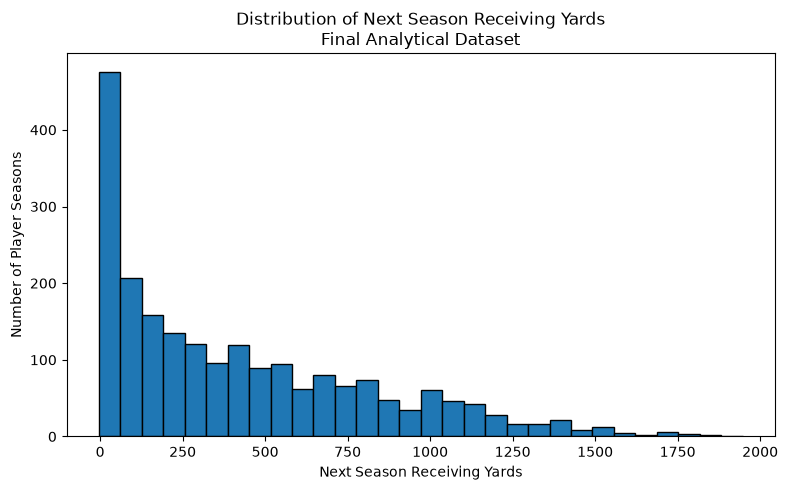

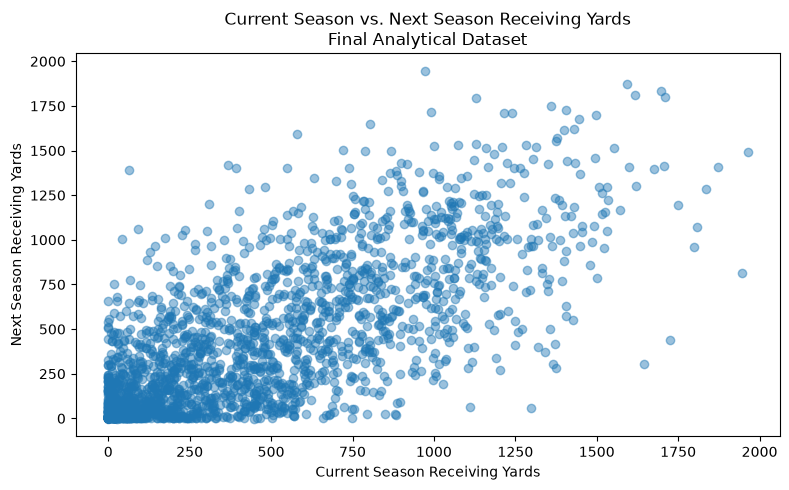

In [23]:
# Validate key EDA relationships in the final analytical dataset

import matplotlib.pyplot as plt
import pandas as pd

final_eda = wr_model.select(
    [
        "receiving_yards",
        "targets",
        "next_season_receiving_yards",
    ]
).to_pandas()

print("Final analytical dataset EDA validation")
print(f"Observations: {len(final_eda):,}")
print(f"Variables checked: {final_eda.shape[1]}")

print("\nSummary statistics:")
display(
    final_eda[
        [
            "receiving_yards",
            "targets",
            "next_season_receiving_yards",
        ]
    ].describe().round(2)
)

print("\nCorrelations:")
display(
    final_eda[
        [
            "receiving_yards",
            "targets",
            "next_season_receiving_yards",
        ]
    ].corr().round(3)
)

plt.figure(figsize=(8, 5))
plt.hist(
    final_eda["next_season_receiving_yards"].dropna(),
    bins=30,
    edgecolor="black",
)
plt.xlabel("Next Season Receiving Yards")
plt.ylabel("Number of Player Seasons")
plt.title(
    "Distribution of Next Season Receiving Yards\n"
    "Final Analytical Dataset"
)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    final_eda["receiving_yards"],
    final_eda["next_season_receiving_yards"],
    alpha=0.45,
)
plt.xlabel("Current Season Receiving Yards")
plt.ylabel("Next Season Receiving Yards")
plt.title(
    "Current Season vs. Next Season Receiving Yards\n"
    "Final Analytical Dataset"
)
plt.tight_layout()
plt.show()

### Final Analytical Dataset EDA Interpretation

The final analytical dataset contains 2,129 player season observations. Receiving production remains right skewed, with median next season receiving yards of 302 compared with a mean of 421.12 yards. This indicates that a smaller group of high production receivers raises the overall average.

Current season receiving yards remain strongly associated with next season receiving yards, with a Pearson correlation of 0.726. Targets also remain positively associated with next season receiving yards, with a correlation of 0.705. Current season receiving yards and targets are themselves highly correlated at 0.968, confirming the substantial overlap between opportunity and production identified during the initial exploratory analysis.

These results confirm that the principal relationships identified in Notebook 03 remain present after target construction, preprocessing, feature engineering, and leakage controls. Historical production and opportunity therefore provide meaningful predictive signal, but neither relationship is strong enough to support next season forecasts on its own. This supports the use of multivariable models while also reinforcing the need to address redundancy among related predictors.